In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Supply Chain Dataset.csv',encoding='latin1')

In [5]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [6]:
df.shape

(180519, 53)

In [9]:
for i,col in enumerate(df.columns):
    print(i,col)


0 Type
1 Days for shipping (real)
2 Days for shipment (scheduled)
3 Benefit per order
4 Sales per customer
5 Delivery Status
6 Late_delivery_risk
7 Category Id
8 Category Name
9 Customer City
10 Customer Country
11 Customer Email
12 Customer Fname
13 Customer Id
14 Customer Lname
15 Customer Password
16 Customer Segment
17 Customer State
18 Customer Street
19 Customer Zipcode
20 Department Id
21 Department Name
22 Latitude
23 Longitude
24 Market
25 Order City
26 Order Country
27 Order Customer Id
28 order date (DateOrders)
29 Order Id
30 Order Item Cardprod Id
31 Order Item Discount
32 Order Item Discount Rate
33 Order Item Id
34 Order Item Product Price
35 Order Item Profit Ratio
36 Order Item Quantity
37 Sales
38 Order Item Total
39 Order Profit Per Order
40 Order Region
41 Order State
42 Order Status
43 Order Zipcode
44 Product Card Id
45 Product Category Id
46 Product Description
47 Product Image
48 Product Name
49 Product Price
50 Product Status
51 shipping date (DateOrders)
52 Sh

In [10]:
df_clean = df.drop(columns =[
    'Customer Email',
    'Customer Password',
    'Customer Street',
    'Customer Zipcode',
    'Product Description',
    'Product Image',
    'Order Zipcode'])
    

In [11]:
df_clean.shape

(180519, 46)

In [13]:
df_clean['Delivery Status'].value_counts()

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

In [14]:
df_clean['Shipping Mode'].value_counts()

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

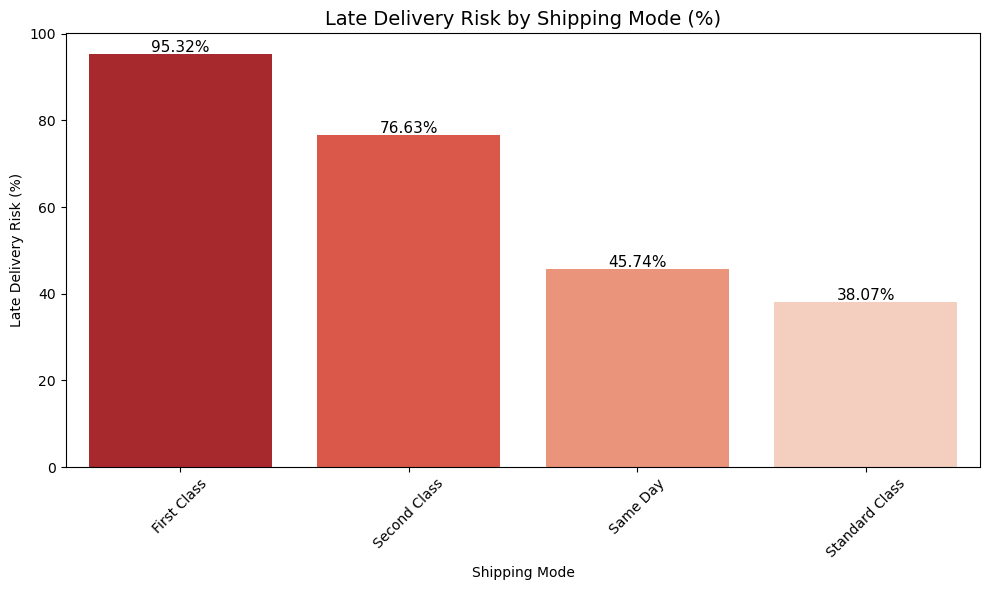

In [20]:
shipping_delivery = df_clean.groupby('Shipping Mode')['Late_delivery_risk'].mean()*100
shipping_delivery = shipping_delivery.round(2).sort_values(ascending = False)

plt.figure(figsize=(10,6))
sns.barplot(x=shipping_delivery.index,y=shipping_delivery.values,hue=shipping_delivery.index,palette='Reds_r',legend =False)
plt.title('Late Delivery Risk by Shipping Mode (%)', fontsize=14)
plt.xlabel('Shipping Mode')
plt.ylabel('Late Delivery Risk (%)')
plt.xticks(rotation =45)

for i, v in enumerate(shipping_delivery.values):
    plt.text(i,v+0.5,f'{v}%', ha='center',fontsize=11)

plt.tight_layout()
plt.savefig('Late Delivery By Shipping Mode.png')
plt.show()

In [22]:
df_clean['Market'].value_counts()

Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64

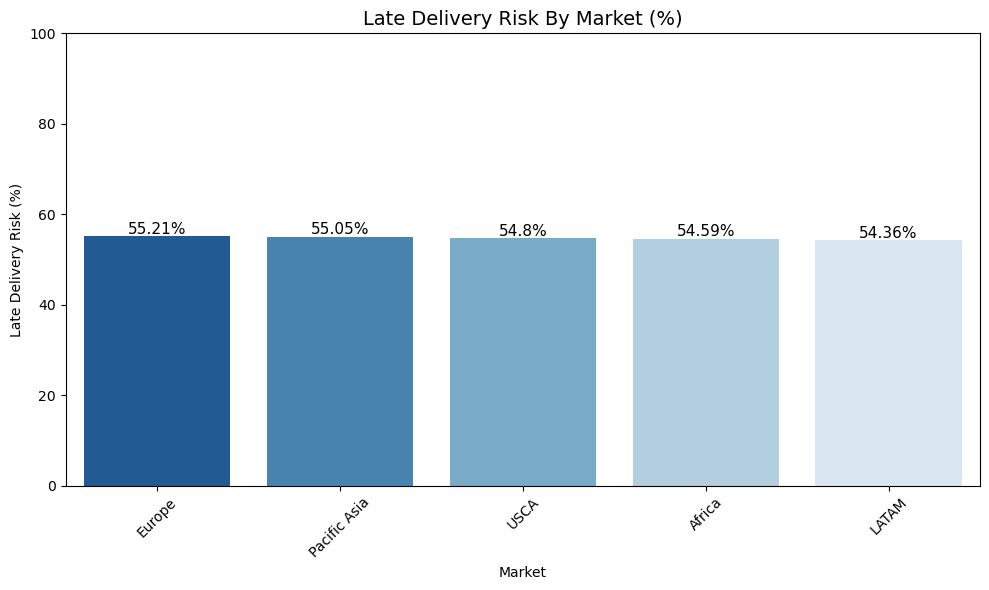

In [26]:
market_delivery = df_clean.groupby('Market')['Late_delivery_risk'].mean()*100
market_delivery = market_delivery.round(2).sort_values(ascending =False)

plt.figure(figsize=(10,6))
sns.barplot(x=market_delivery.index,y=market_delivery.values,hue=market_delivery.index,palette='Blues_r',legend= False)
plt.ylim(0,100)
plt.title('Late Delivery Risk By Market (%)',fontsize=14)
plt.xlabel('Market')
plt.ylabel('Late Delivery Risk (%)')
plt.xticks(rotation=45)

for i, v in enumerate (market_delivery.values):
    plt.text(i,v+0.5,f'{v}%',ha='center',fontsize=11)

plt.tight_layout()
plt.savefig('Late Delivery By Market.png')
plt.show()

In [30]:
late_vs_ontime = df_clean.groupby('Late_delivery_risk')[['Benefit per order','Order Profit Per Order']].mean()
print(late_vs_ontime)

                    Benefit per order  Order Profit Per Order
Late_delivery_risk                                           
0                           22.403808               22.403808
1                           21.621707               21.621707


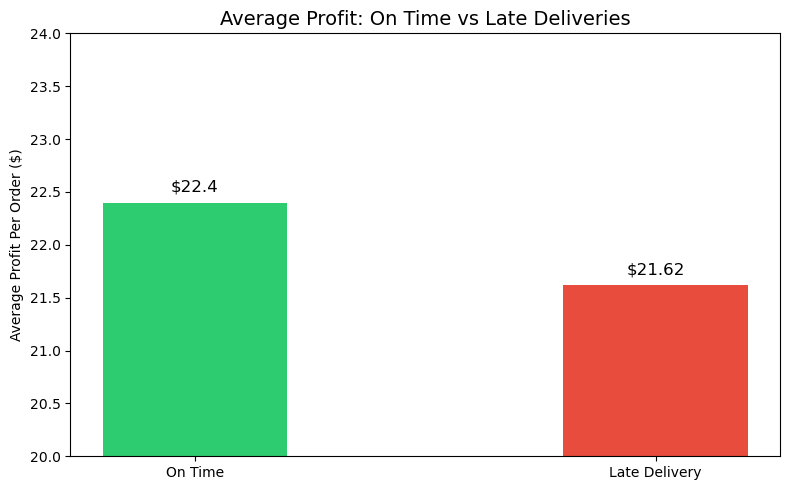

In [35]:
fig, ax = plt.subplots(figsize=(8,5))

labels = ['On Time','Late Delivery']
profits = [22.40,21.62]
colors = ['#2ecc71','#e74c3c']

bars = ax.bar(labels,profits,color = colors, width =0.4)

for bar,profit in zip(bars,profits):
    ax.text(bar.get_x() + bar.get_width()/2,bar.get_height()+0.1, f'${profit}',ha='center',fontsize=12)

ax.set_title('Average Profit: On Time vs Late Deliveries',fontsize=14)
ax.set_ylabel('Average Profit Per Order ($)')
ax.set_ylim(20,24)

plt.tight_layout()
plt.savefig('Profit Impact Late Delivery.png')
plt.show()

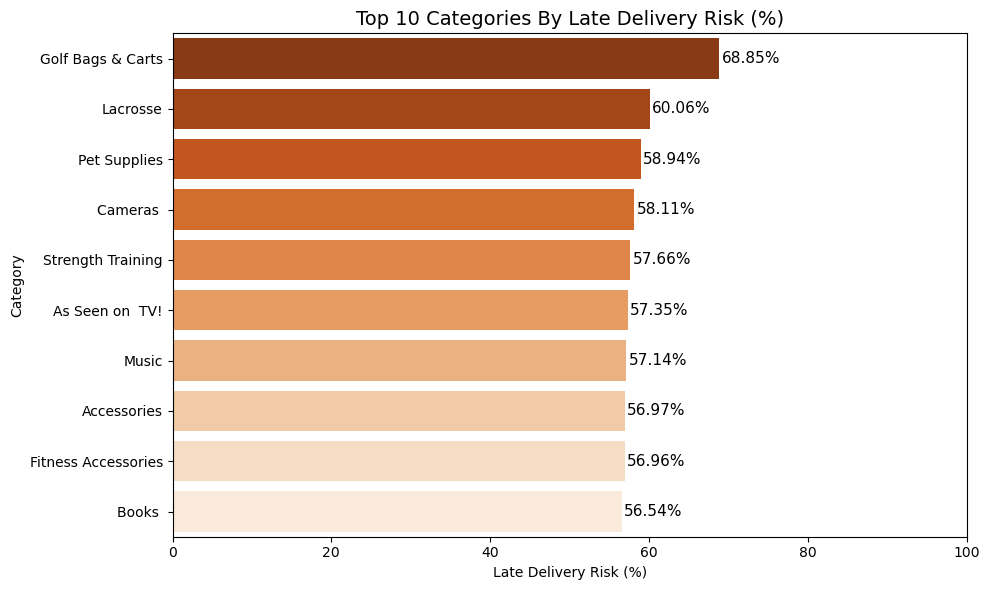

In [40]:
category_delivery = df_clean.groupby('Category Name')['Late_delivery_risk'].mean()*100
category_delivery = category_delivery.round(2).sort_values(ascending =False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=category_delivery.values,y=category_delivery.index,hue=category_delivery.index,palette ='Oranges_r',legend =False)
plt.title('Top 10 Categories By Late Delivery Risk (%)',fontsize=14)
plt.xlabel('Late Delivery Risk (%)')
plt.xlim(0,100)
plt.ylabel('Category')

for i, v in enumerate(category_delivery.values):
    plt.text(v+0.3,i,f'{v}%', va='center',fontsize=11)

plt.tight_layout()
plt.savefig('Late Delivery By Category.png')
plt.show()